In [1]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
db = wrds.Connection()


Enter your WRDS username [tan]: shujietan
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  n


You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
def get_stock_data(ticker, start_date):
    sql = f"""
    SELECT b.htsymbol, b.permno, a.date, a.prc, a.ret
    FROM crsp.msf AS a
    LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
    WHERE b.htsymbol = '{ticker}'
    AND a.date >= '{start_date}'
    """
    df = db.raw_sql(sql)
    return df


In [5]:
df = get_stock_data(ticker="AAPL", start_date="2020-01-01")

In [6]:
print(df.head())

  htsymbol  permno        date        prc       ret
0     AAPL   14593  2020-01-31  309.51001   0.05401
1     AAPL   14593  2020-02-28  273.35999  -0.11431
2     AAPL   14593  2020-03-31  254.28999 -0.069762
3     AAPL   14593  2020-04-30  293.79999  0.155374
4     AAPL   14593  2020-05-29     317.94  0.084956


In [7]:
df = df.rename(columns={"htsymbol":"ticker","prc":"price","ret":"return"})

In [8]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values("date")

In [9]:
df = df.dropna(subset=["price","return"])

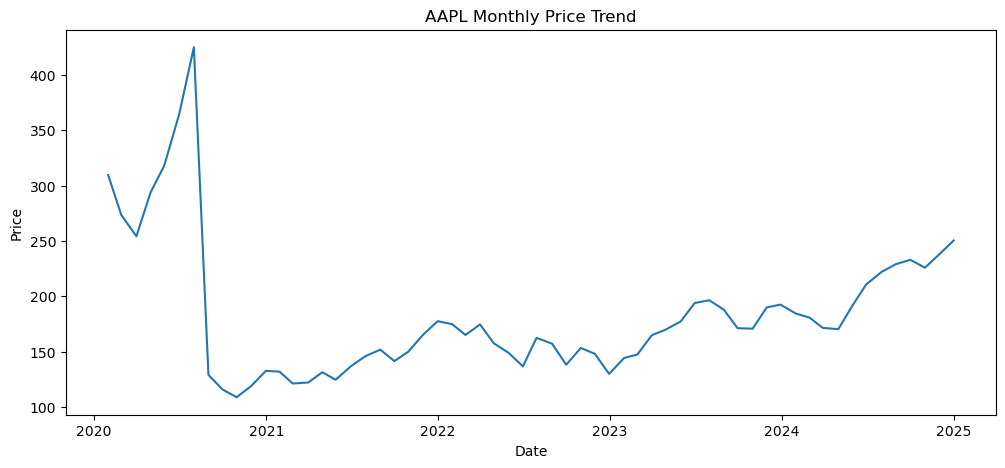

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df.date, df.price)
plt.title("AAPL Monthly Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.savefig("price_trend.png")
plt.show()


In [11]:
print(df.head().to_markdown())

|    | ticker   |   permno | date                |   price |    return |
|---:|:---------|---------:|:--------------------|--------:|----------:|
|  0 | AAPL     |    14593 | 2020-01-31 00:00:00 |  309.51 |  0.05401  |
|  1 | AAPL     |    14593 | 2020-02-28 00:00:00 |  273.36 | -0.11431  |
|  2 | AAPL     |    14593 | 2020-03-31 00:00:00 |  254.29 | -0.069762 |
|  3 | AAPL     |    14593 | 2020-04-30 00:00:00 |  293.8  |  0.155374 |
|  4 | AAPL     |    14593 | 2020-05-29 00:00:00 |  317.94 |  0.084956 |
